# Exercise 07 — Arrays and Numerical Linear Algebra

NUMA01 VT2026 — Arvid Brenner & Sixten Midsem

Lösningar till `exercise07.md`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Task 2 — Bug-fix: matvec

Studentens kod hade flera fel:

1. `y = x` — alias, vi skriver senare över *indata*. Bör vara `np.zeros`.
2. `range(1, A.shape[0])` — börjar på 1 i stället för 0.
3. Fel form: `A.shape[0]` är **antal rader**, `A.shape[1]` är **antal kolumner**.
   Yttre loop ska gå över rader (`A.shape[0]`), inre över kolumner (`A.shape[1]`).
4. `y[r] = A[c, r] * x[r]` — överskriver i stället för ackumulerar, och
   indexen är fel ordning. Rätt: `y[r] += A[r, c] * x[c]`.

Och så finns ju `A @ x` som bara gör samma sak vektoriserat.


In [2]:
def matvec(A, x):
    """Returnera y = A x."""
    assert A.shape[1] == len(x), "A:s kolumner måste matcha x:s längd"
    y = np.zeros(A.shape[0])
    for r in range(A.shape[0]):
        for c in range(A.shape[1]):
            y[r] += A[r, c] * x[c]
    return y


x = np.array([1., 2., 3.])
M = np.array([[1., 2., 3.],
              [4., 5., 6.]])

z = matvec(M, x)
print("matvec:", z)
print("M @ x :", M @ x)
assert np.allclose(z, M @ x)


matvec: [14. 32.]
M @ x : [14. 32.]


## Task 3 — Reella symmetriska matriser har reella egenvärden + ortogonala egenvektorer

Vi konstruerar en slumpmässig symmetrisk matris som $A = (B + B^T)/2$ och
kontrollerar att (i) egenvärdena är reella och (ii) egenvektorerna är
ortonormala (dvs $V^T V = I$).


In [3]:
rng = np.random.default_rng(0)

for n in [5, 8, 12]:
    B = rng.standard_normal((n, n))
    A = (B + B.T) / 2
    w, V = np.linalg.eig(A)

    print(f"n = {n}")
    print(f"  max |Im(eigvals)| = {np.max(np.abs(w.imag)):.2e}")
    print(f"  max |V^T V - I|   = {np.max(np.abs(V.T @ V - np.eye(n))):.2e}")


n = 5
  max |Im(eigvals)| = 0.00e+00
  max |V^T V - I|   = 7.92e-16
n = 8
  max |Im(eigvals)| = 0.00e+00
  max |V^T V - I|   = 5.88e-16
n = 12
  max |Im(eigvals)| = 0.00e+00
  max |V^T V - I|   = 1.04e-15


## Task 4 — Tridiagonal $-2, 1, 1$

`diag` med offset bygger sub/super-diagonalen. Detta är diskreta Laplace-
operatorn (utan randvillkor), och approximerar andraderivatan via
$(u_{i-1} - 2 u_i + u_{i+1})/h^2$.


In [4]:
def laplace_matrix(n):
    """n×n tridiagonal: -2 på diagonalen, 1 på sub/super."""
    return -2 * np.eye(n) + np.diag(np.ones(n-1), 1) + np.diag(np.ones(n-1), -1)


print(laplace_matrix(5))


[[-2.  1.  0.  0.  0.]
 [ 1. -2.  1.  0.  0.]
 [ 0.  1. -2.  1.  0.]
 [ 0.  0.  1. -2.  1.]
 [ 0.  0.  0.  1. -2.]]


## Task 5 — Diskret andraderivata av $\sin x$

Med `x = linspace(0, 2π, 500)` och `D = laplace_matrix(500)` blir `D u`
en oskalad andraderivata. Steget är $h = 2\pi/(n-1)$, så
$u'' \approx D u / h^2$. Andraderivatan av $\sin x$ är $-\sin x$.


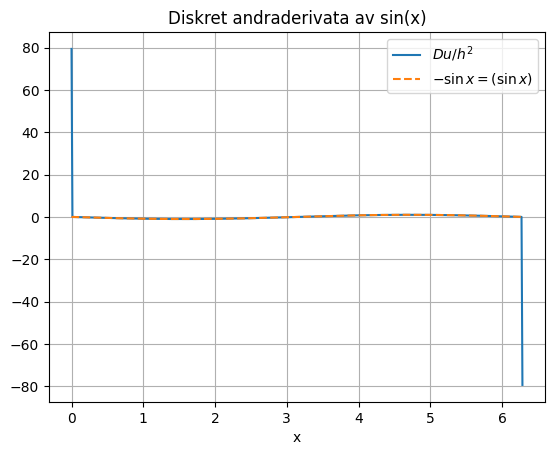

max |D u/h^2 - (-sin x)| (interna punkter): 1.3212133310624985e-05


In [5]:
x = np.linspace(0, 2 * np.pi, 500)
u = np.sin(x)
h = x[1] - x[0]
D = laplace_matrix(len(u))
y = D @ u / h ** 2

plt.figure()
plt.plot(x, y, label=r'$D u / h^2$')
plt.plot(x, -np.sin(x), '--', label=r'$-\sin x = (\sin x)''$')
plt.xlabel('x'); plt.legend(); plt.grid(True)
plt.title('Diskret andraderivata av sin(x)')
plt.show()

# Felet är stort vid randerna eftersom matrisen ignorerar randvillkor:
inner = slice(1, -1)
print("max |D u/h^2 - (-sin x)| (interna punkter):",
      np.max(np.abs(y[inner] - (-np.sin(x))[inner])))
